In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
history = pd.read_csv("TCS_stock_history.csv")
actions = pd.read_csv("TCS_stock_history.csv")
info = pd.read_csv("TCS_stock_info.csv")

In [3]:
history["Date"] = pd.to_datetime(history["Date"])
actions["Date"] = pd.to_datetime(actions["Date"])

In [4]:
actions.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-08-12,28.794172,29.742206,28.794172,29.519140,212976,0.0,0.0
1,2002-08-13,29.556316,30.030333,28.905705,29.119476,153576,0.0,0.0
2,2002-08-14,29.184536,29.184536,26.563503,27.111877,822776,0.0,0.0
3,2002-08-15,27.111877,27.111877,27.111877,27.111877,0,0.0,0.0
4,2002-08-16,26.972458,28.255089,26.582090,27.046812,811856,0.0,0.0


In [5]:
history = history.sort_values("Date")
actions = actions.sort_values("Date")

In [6]:
history.set_index("Date", inplace=True)
actions.set_index("Date", inplace=True)

In [7]:
print("History")
print(history.head())
print(history.info())

print("\n")

print("Actions")
print(actions.head())
print(actions.info())

History
                 Open       High        Low      Close  Volume  Dividends  \
Date                                                                        
2002-08-12  28.794172  29.742206  28.794172  29.519140  212976        0.0   
2002-08-13  29.556316  30.030333  28.905705  29.119476  153576        0.0   
2002-08-14  29.184536  29.184536  26.563503  27.111877  822776        0.0   
2002-08-15  27.111877  27.111877  27.111877  27.111877       0        0.0   
2002-08-16  26.972458  28.255089  26.582090  27.046812  811856        0.0   

            Stock Splits  
Date                      
2002-08-12           0.0  
2002-08-13           0.0  
2002-08-14           0.0  
2002-08-15           0.0  
2002-08-16           0.0  
<class 'pandas.DataFrame'>
DatetimeIndex: 4463 entries, 2002-08-12 to 2021-09-30
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          4463 non-null   float64
 1   High          44

In [8]:
# Difference between consecutive dates
date_diff = history.index.to_series().diff().value_counts().sort_index()

print(date_diff)

Date
1 days      3401
2 days       112
3 days       846
4 days        93
5 days         7
6 days         1
13 days        1
400 days       1
Name: count, dtype: int64


In [9]:
history["Return"] = history["Close"].pct_change()

# Remove the first NaN created by pct_change
history = history.dropna()

history.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Return
Date,,,,,,,,
2002-08-13,29.556316,30.030333,28.905705,29.119476,153576,0.0,0.0,-0.013539
2002-08-14,29.184536,29.184536,26.563503,27.111877,822776,0.0,0.0,-0.068944
2002-08-15,27.111877,27.111877,27.111877,27.111877,0,0.0,0.0,0.000000
2002-08-16,26.972458,28.255089,26.582090,27.046812,811856,0.0,0.0,-0.002400
2002-08-19,27.269876,27.269876,26.126661,26.377609,205880,0.0,0.0,-0.024742


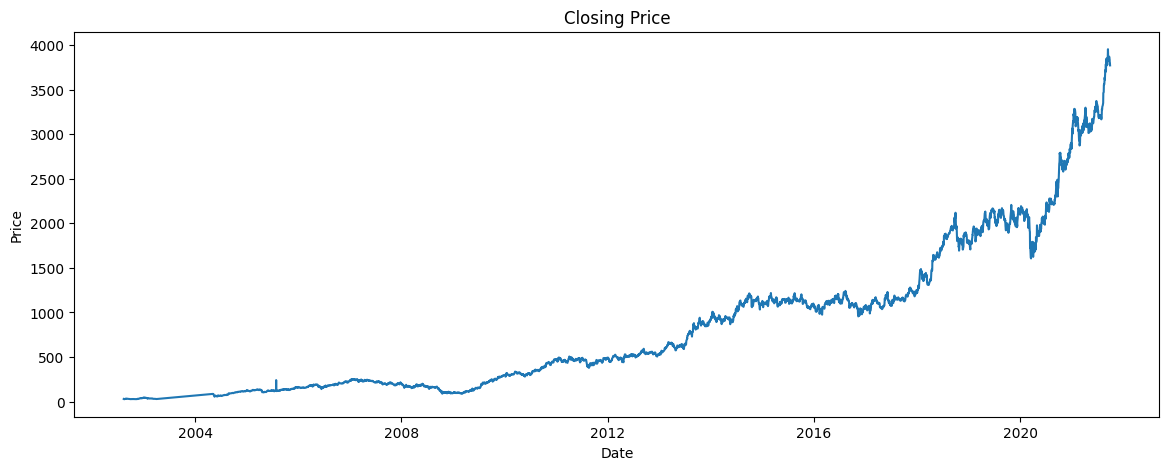

In [10]:
plt.figure(figsize=(14,5))

plt.plot(history.index, history["Close"])
plt.title("Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

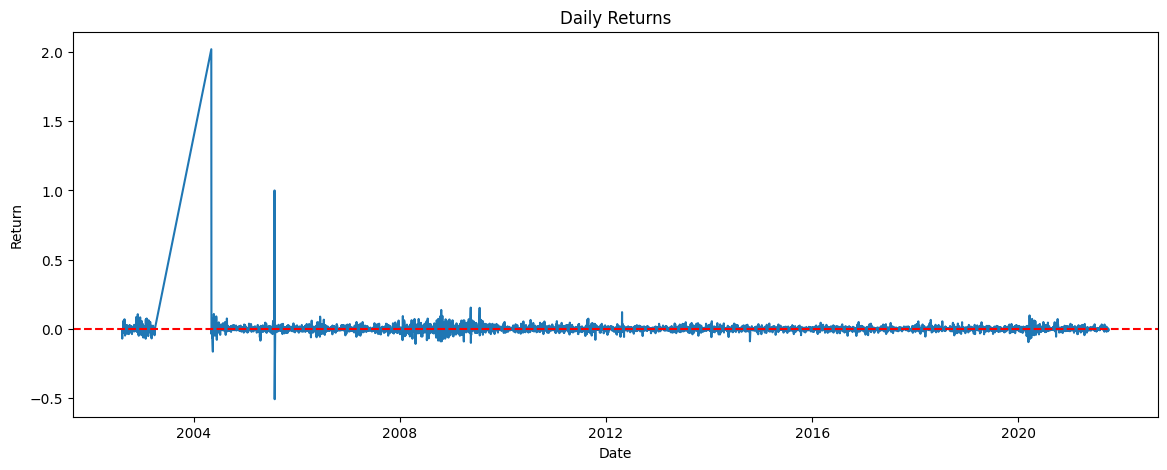

In [11]:
plt.figure(figsize=(14,5))

plt.plot(history.index, history["Return"])
plt.title("Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")

plt.axhline(0, color="red", linestyle="--")

plt.show()

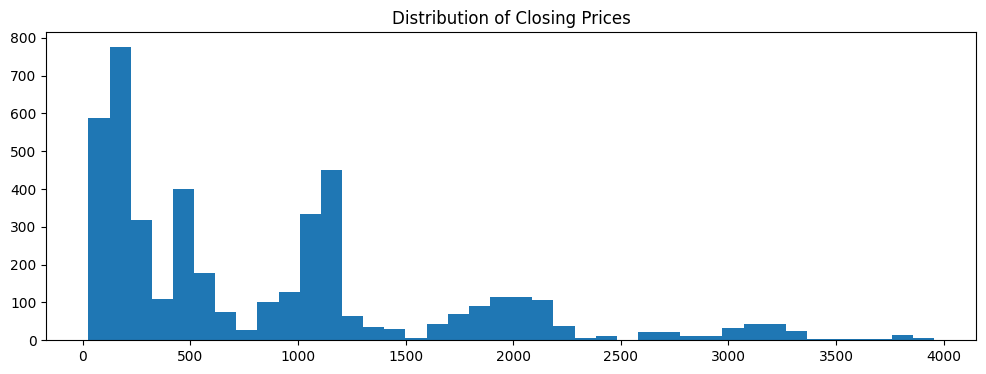

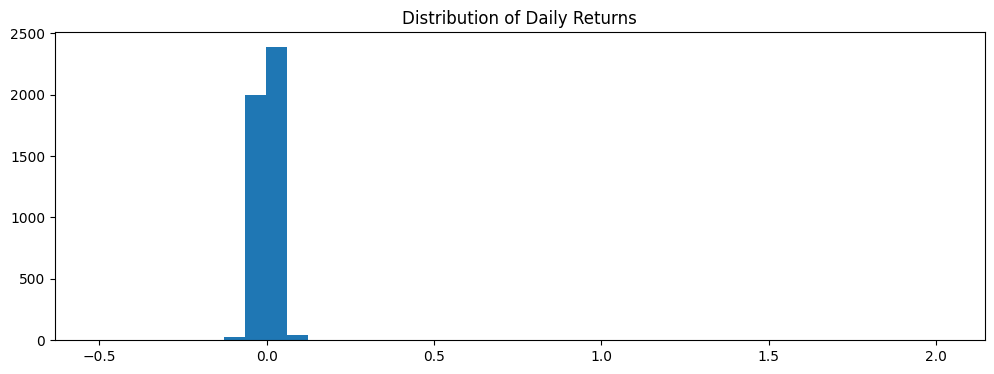

In [12]:
plt.figure(figsize=(12,4))

plt.hist(history["Close"], bins=40)
plt.title("Distribution of Closing Prices")

plt.show()
plt.figure(figsize=(12,4))

plt.hist(history["Return"], bins=40)
plt.title("Distribution of Daily Returns")

plt.show()

In [16]:
history["MA50"] = history["Close"].rolling(window=50).mean()


history["MA90"] = history["Close"].rolling(window=90).mean()

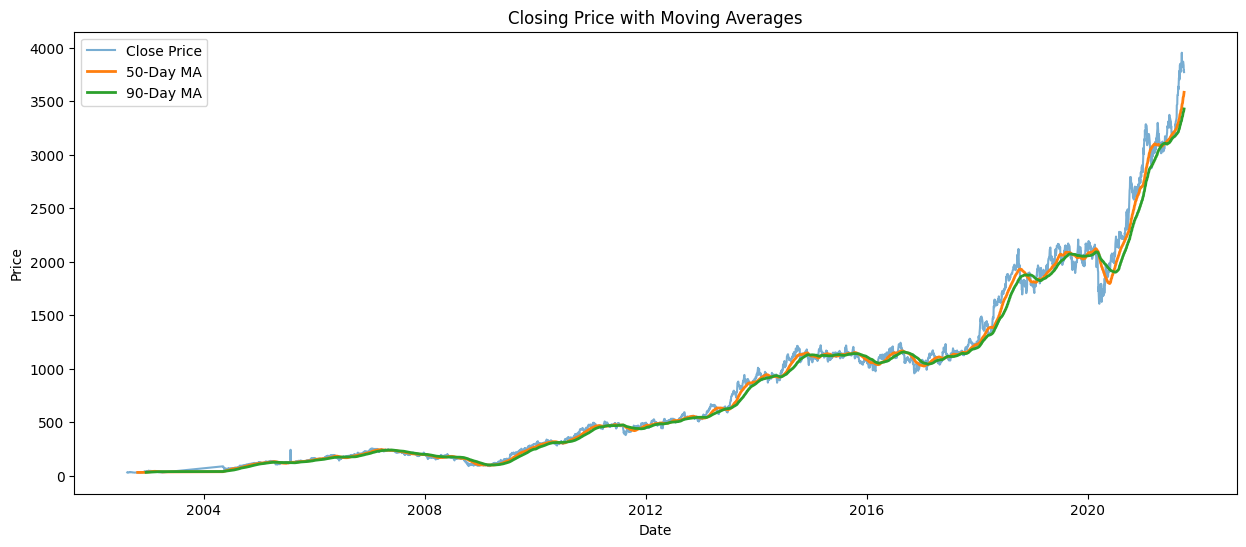

In [18]:

plt.figure(figsize=(15,6))

plt.plot(history.index, history["Close"], label="Close Price", alpha=0.6)
plt.plot(history.index, history["MA50"], label="50-Day MA", linewidth=2)
plt.plot(history.index, history["MA90"], label="90-Day MA", linewidth=2)

plt.title("Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.show()

In [19]:
history["Volatility20"] = history["Return"].rolling(window=20).std()

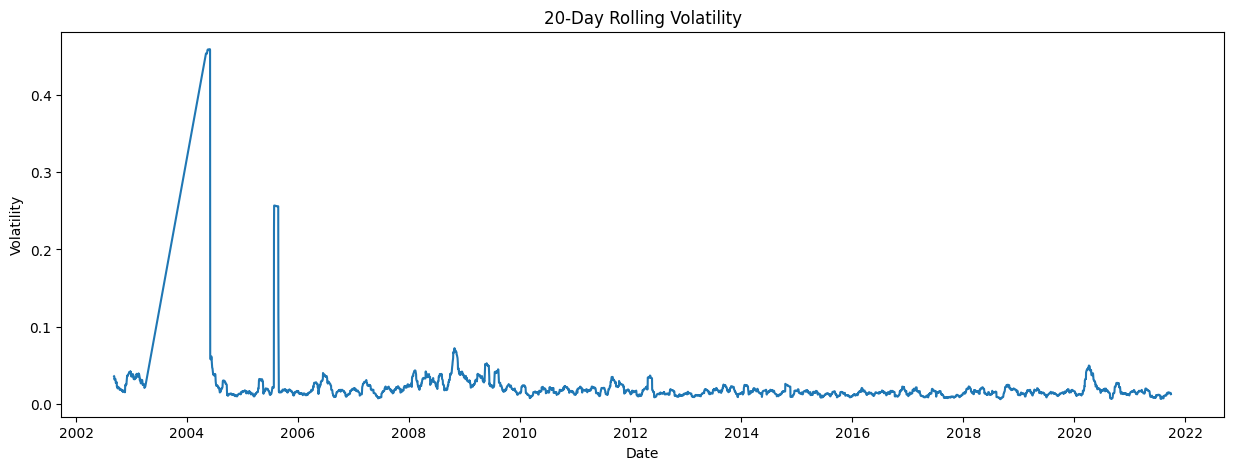

In [20]:
plt.figure(figsize=(15,5))

plt.plot(history.index, history["Volatility20"])

plt.title("20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.show()

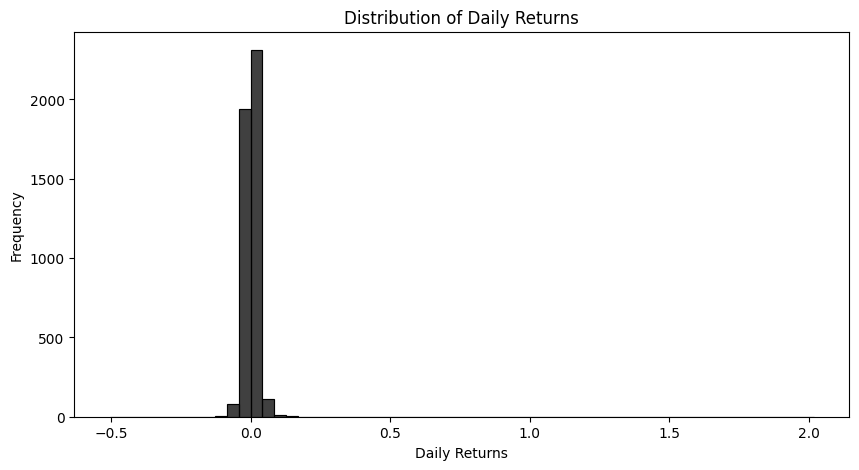

In [23]:
plt.figure(figsize=(10, 5))

sns.histplot(history["Return"],bins=60, color="black")

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Returns")
plt.ylabel("Frequency")

plt.show()

In [24]:
print(history["Return"].describe())

count    4462.000000
mean        0.001613
std         0.040109
min        -0.506111
25%        -0.009086
50%         0.000424
75%         0.010963
max         2.018887
Name: Return, dtype: float64


In [27]:
# Golden rule: features use only information available up to today, while the target is tomorrow's direction.
history["Target"] = (history["Return"].shift(-1) > 0).astype(int)
history = history.dropna(subset=["Target"]).copy()

history[["Close", "Return", "Target"]].head()


,Close,Return,Target
Date,,,
2002-08-13,29.119476,-0.013539,0
2002-08-14,27.111877,-0.068944,0
2002-08-15,27.111877,0.000000,0
2002-08-16,27.046812,-0.002400,0
2002-08-19,26.377609,-0.024742,1


In [28]:
# Lag and rolling features from past information only.
# Every feature below looks backward in time, so it does not use future information.
history = history.copy()

history["Lag_1_Return"] = history["Return"].shift(1)
history["Lag_3_Return"] = history["Return"].shift(3)
history["Lag_5_Return"] = history["Return"].shift(5)

history["Rolling_Mean_3"] = history["Return"].shift(1).rolling(window=3).mean()
history["Rolling_Mean_5"] = history["Return"].shift(1).rolling(window=5).mean()
history["Rolling_Std_5"] = history["Return"].shift(1).rolling(window=5).std()
history["Momentum_5"] = history["Close"].pct_change(5)

feature_cols = [
    "Lag_1_Return",
    "Lag_3_Return",
    "Lag_5_Return",
    "Rolling_Mean_3",
    "Rolling_Mean_5",
    "Rolling_Std_5",
    "Momentum_5",
]

history = history.dropna(subset=["Target"] + feature_cols).copy()

history[["Close", "Return", "Target"] + feature_cols].head()


,Close,Return,Target,Lag_1_Return,Lag_3_Return,Lag_5_Return,Rolling_Mean_3,Rolling_Mean_5,Rolling_Std_5,Momentum_5
Date,,,,,,,,,,
2002-08-20,27.111877,0.027837,1,-0.024742,0.000000,-0.013539,-0.009047,-0.021925,0.028067,-0.068944
2002-08-21,28.440964,0.049022,1,0.027837,-0.002400,-0.068944,0.000232,-0.013650,0.036106,0.049022
2002-08-22,29.667849,0.043138,1,0.049022,-0.024742,0.000000,0.017372,0.009943,0.028730,0.094275
2002-08-23,31.452364,0.060150,0,0.043138,0.027837,-0.002400,0.039999,0.018571,0.031355,0.162886
2002-08-26,31.340841,-0.003546,0,0.060150,0.049022,-0.024742,0.050770,0.031081,0.033313,0.188161
